# 08 - Bilateral Filtering and Edge Preservation

For center pixel \(p\) and neighbor \(q\), bilateral weights combine spatial distance and intensity difference. The parameters \(\sigma_s\) and \(\sigma_r\) control spatial support and range similarity, respectively.

In [1]:
from pathlib import Path
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

def find_course_root() -> Path:
    """Locate the cloned course repository without a machine-specific path."""
    candidates = []
    configured = os.environ.get("VISION_ROBOTICA_REPO")
    if configured:
        candidates.append(Path(configured).expanduser())
    current = Path.cwd().resolve()
    candidates.extend([current, *current.parents])
    for candidate in candidates:
        if (candidate / "imagenes").is_dir() and (candidate / "requirements.txt").is_file():
            return candidate
    raise FileNotFoundError(
        "Course repository not found. Run the notebook from the cloned repository root "
        "or define VISION_ROBOTICA_REPO."
    )

ROOT = find_course_root()
COURSE_IMAGES = ROOT / "imagenes"
STUDENT_IMAGES = ROOT / "student_work" / "imagenes"
STUDENT_IMAGES.mkdir(parents=True, exist_ok=True)

def load_rgb(filename: str) -> np.ndarray:
    path = COURSE_IMAGES / filename
    image_bgr = cv2.imread(str(path), cv2.IMREAD_COLOR)
    if image_bgr is None:
        raise FileNotFoundError(f"Official course image not found: {path}")
    return cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)

print(f"Course root: {ROOT}")
print(f"Official images: {COURSE_IMAGES}")
print(f"Student images: {STUDENT_IMAGES}")

Course root: C:\Users\20808\Documents\Repositorios\Vision_en_Robotica
Official images: C:\Users\20808\Documents\Repositorios\Vision_en_Robotica\imagenes
Student images: C:\Users\20808\Documents\Repositorios\Vision_en_Robotica\student_work\imagenes


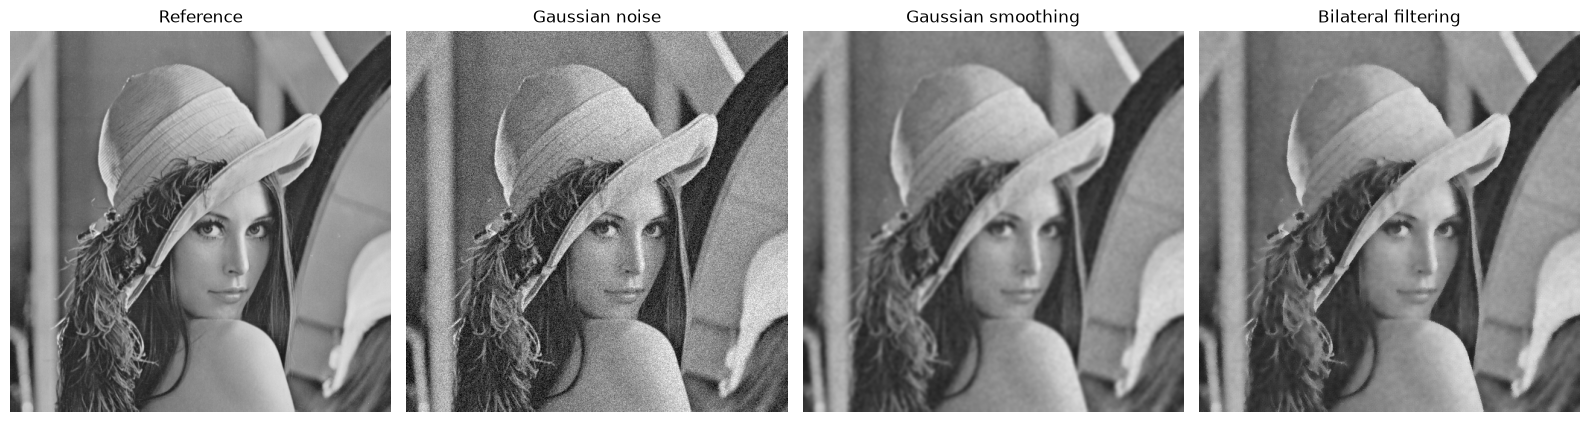

In [2]:
from skimage.metrics import structural_similarity

image_rgb = load_rgb("lenna.png")
reference = cv2.cvtColor(image_rgb, cv2.COLOR_RGB2GRAY)
rng = np.random.default_rng(4012)
noisy = np.clip(reference.astype(np.float32) + rng.normal(0, 18, reference.shape), 0, 255).astype(np.uint8)

gaussian = cv2.GaussianBlur(noisy, (9, 9), 2.0)
bilateral = cv2.bilateralFilter(noisy, d=9, sigmaColor=45, sigmaSpace=45)

fig, axes = plt.subplots(1, 4, figsize=(16, 5))
for axis, image, title in zip(
    axes,
    [reference, noisy, gaussian, bilateral],
    ["Reference", "Gaussian noise", "Gaussian smoothing", "Bilateral filtering"],
):
    axis.imshow(image, cmap="gray", vmin=0, vmax=255)
    axis.set_title(title)
    axis.axis("off")
plt.tight_layout()
plt.show()

In [3]:
def mse(reference: np.ndarray, test: np.ndarray) -> float:
    delta = reference.astype(np.float64) - test.astype(np.float64)
    return float(np.mean(delta**2))

def psnr(reference: np.ndarray, test: np.ndarray) -> float:
    error = mse(reference, test)
    return float("inf") if error == 0 else float(10 * np.log10(255.0**2 / error))

def edge_energy(image: np.ndarray) -> float:
    gx = cv2.Sobel(image, cv2.CV_32F, 1, 0)
    gy = cv2.Sobel(image, cv2.CV_32F, 0, 1)
    return float(np.sum(cv2.magnitude(gx, gy)))

baseline_edges = edge_energy(reference)
print(f"{'Result':20s} {'MSE':>10s} {'PSNR':>10s} {'SSIM':>10s} {'Edge ratio':>12s}")
for name, image in {"Noisy": noisy, "Gaussian": gaussian, "Bilateral": bilateral}.items():
    print(
        f"{name:20s} {mse(reference, image):10.2f} {psnr(reference, image):10.2f} "
        f"{structural_similarity(reference, image, data_range=255):10.4f} "
        f"{edge_energy(image)/baseline_edges:12.3f}"
    )

Result                      MSE       PSNR       SSIM   Edge ratio
Noisy                    323.12      23.04     0.4059        2.060
Gaussian                  97.38      28.25     0.7980        0.617
Bilateral                 60.34      30.32     0.8074        0.757


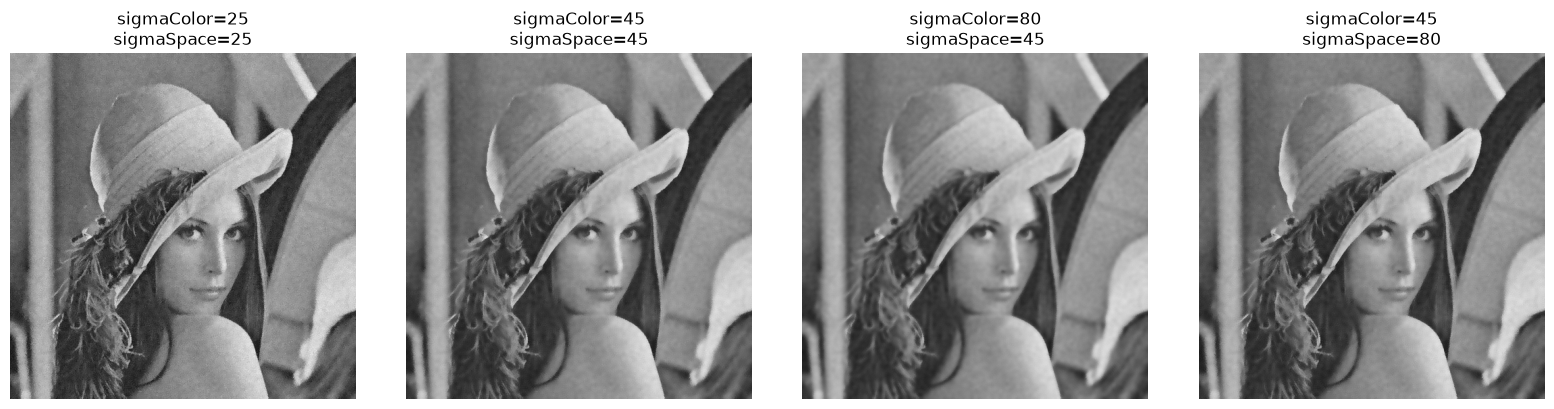

In [4]:
parameter_sets = [(25, 25), (45, 45), (80, 45), (45, 80)]
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for axis, (sigma_color, sigma_space) in zip(axes, parameter_sets):
    result = cv2.bilateralFilter(noisy, 9, sigma_color, sigma_space)
    axis.imshow(result, cmap="gray", vmin=0, vmax=255)
    axis.set_title(f"sigmaColor={sigma_color}\nsigmaSpace={sigma_space}")
    axis.axis("off")
plt.tight_layout()
plt.show()

## Interpretation

Increasing `sigmaColor` allows averaging across larger intensity differences and can weaken edge preservation. Increasing `sigmaSpace` expands the spatial influence. The bilateral filter is justified when its added computation produces measurable task benefit over Gaussian or median filtering.